# Lab Assignment 4
# Pakiza Hassan
# FA23-BAI-034

# Install Libraries & Imports

In [1]:
!pip install -q kagglehub opencv-python matplotlib pandas numpy plotly

import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import kagglehub

print("Libraries loaded successfully!")

Libraries loaded successfully!


# Download Dataset & Select 5 Images

In [2]:
dataset_path = kagglehub.dataset_download(
    "nodoubttome/skin-cancer9-classesisic"
)

print("Dataset downloaded!")
print("Dataset path:", dataset_path)

# Find image files
extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

all_images = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if Path(file).suffix.lower() in extensions:
            all_images.append(os.path.join(root, file))

all_images = sorted(all_images)

print("Total images found:", len(all_images))

# Make sure at least 5 images exist
if len(all_images) < 5:
    raise ValueError("Less than 5 images were found.")

# Select exactly 5 images
selected_images = all_images[:5]

print("\nSelected 5 images:")

for i, path in enumerate(selected_images, 1):
    print(f"Image {i}: {path}")

100%|██████████| 786M/786M [00:37<00:00, 21.7MB/s]

Extracting files...


Dataset downloaded!
Dataset path: /root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1
Total images found: 2357

Selected 5 images:
Image 1: /root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0010512.jpg
Image 2: /root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0010889.jpg
Image 3: /root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0024468.jpg
Image 4: /root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Test/actinic keratosis/ISIC_0024470.jpg
Image 5: /root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic

# Display Original Images

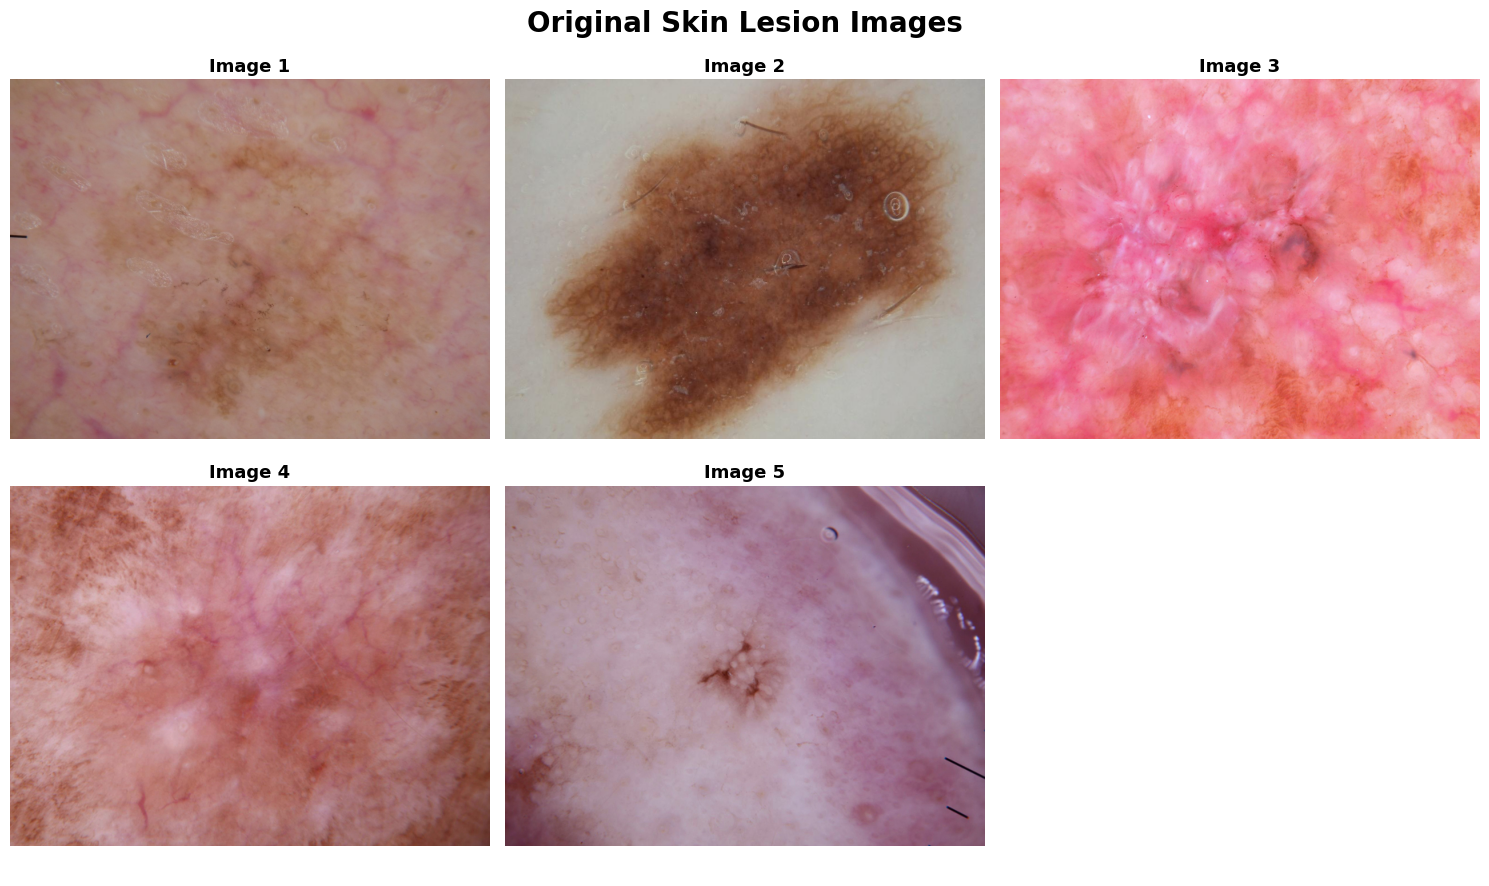

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for i, path in enumerate(selected_images):

    image = cv2.imread(path)

    if image is None:
        raise ValueError(f"Could not read Image {i+1}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    axes[i].imshow(image)
    axes[i].set_title(
        f"Image {i+1}",
        fontsize=13,
        fontweight="bold"
    )
    axes[i].axis("off")

# Hide empty sixth position
axes[5].axis("off")

plt.suptitle(
    "Original Skin Lesion Images",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Grayscale + Average + Gaussian + Median

In [4]:
processed = {}

for i, path in enumerate(selected_images, 1):

    image = cv2.imread(path)

    if image is None:
        raise ValueError(f"Could not read Image {i}")

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Average filter
    average = cv2.blur(gray, (5, 5))

    # Gaussian filter
    gaussian = cv2.GaussianBlur(gray, (5, 5), 0)

    # Median filter
    median = cv2.medianBlur(gray, 5)

    processed[f"Image {i}"] = {
        "original": cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
        "gray": gray,
        "average": average,
        "gaussian": gaussian,
        "median": median
    }

print("Grayscale and filtering completed for all 5 images!")

Grayscale and filtering completed for all 5 images!


# Visualize Preprocessing

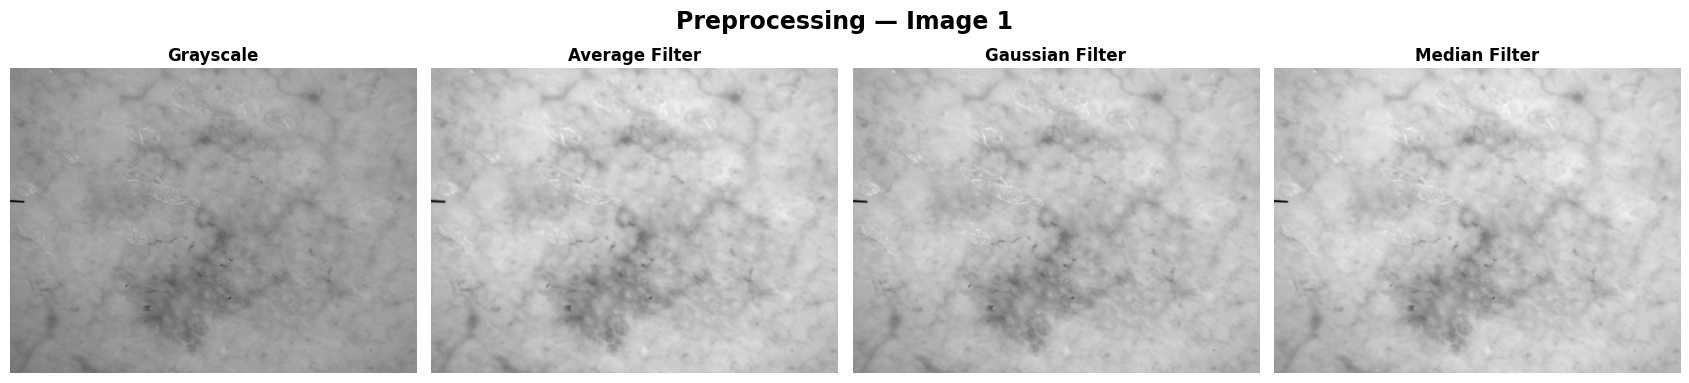

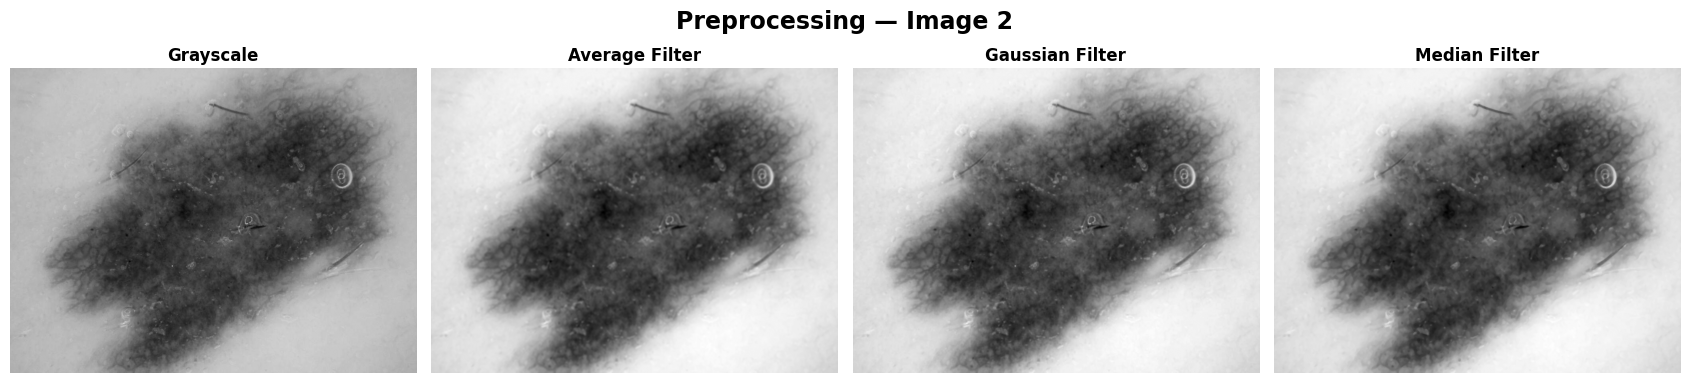

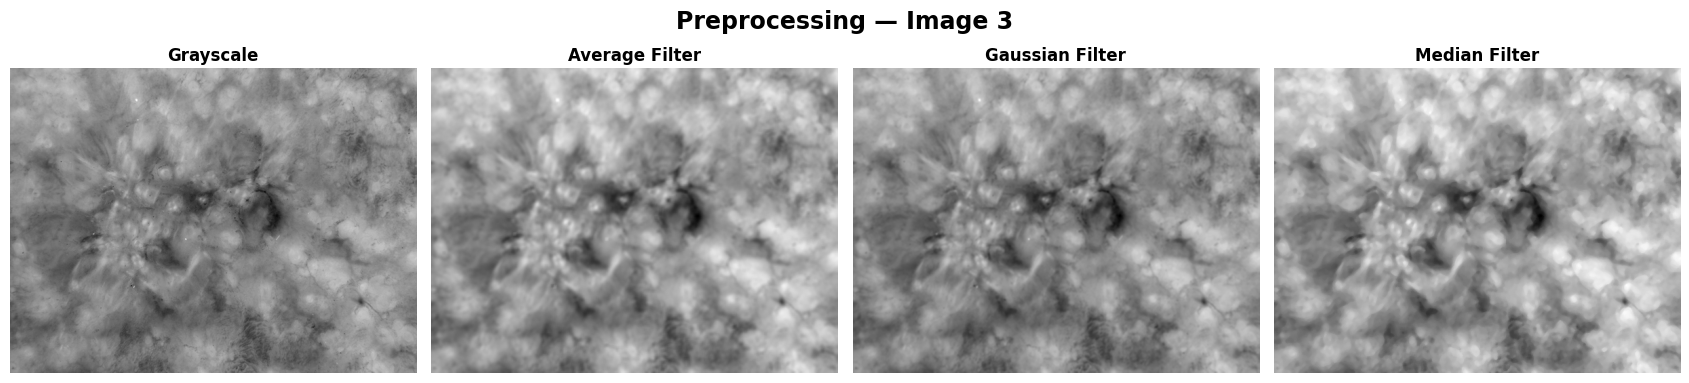

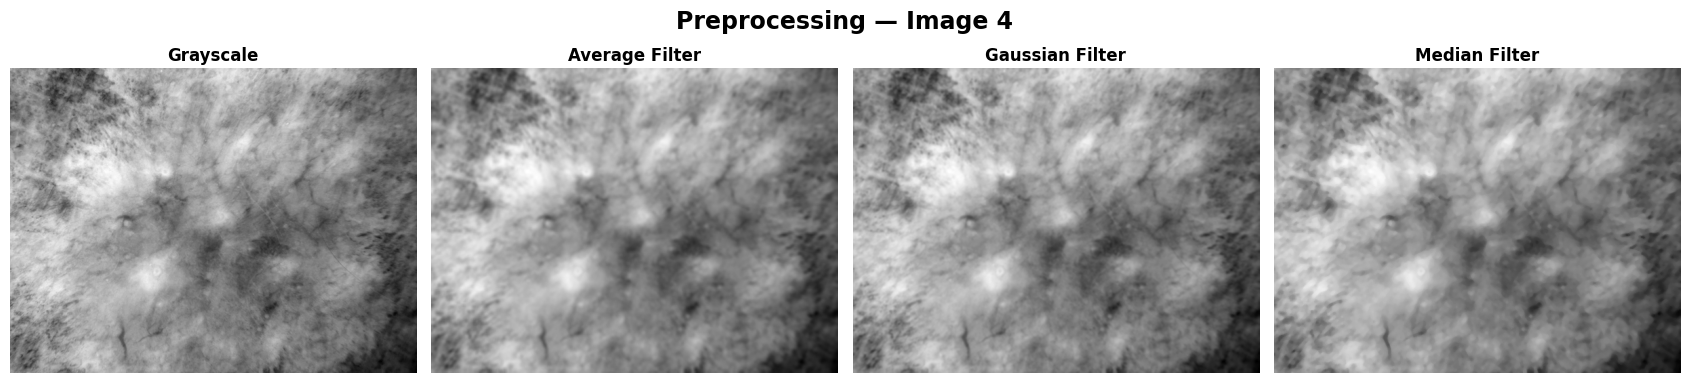

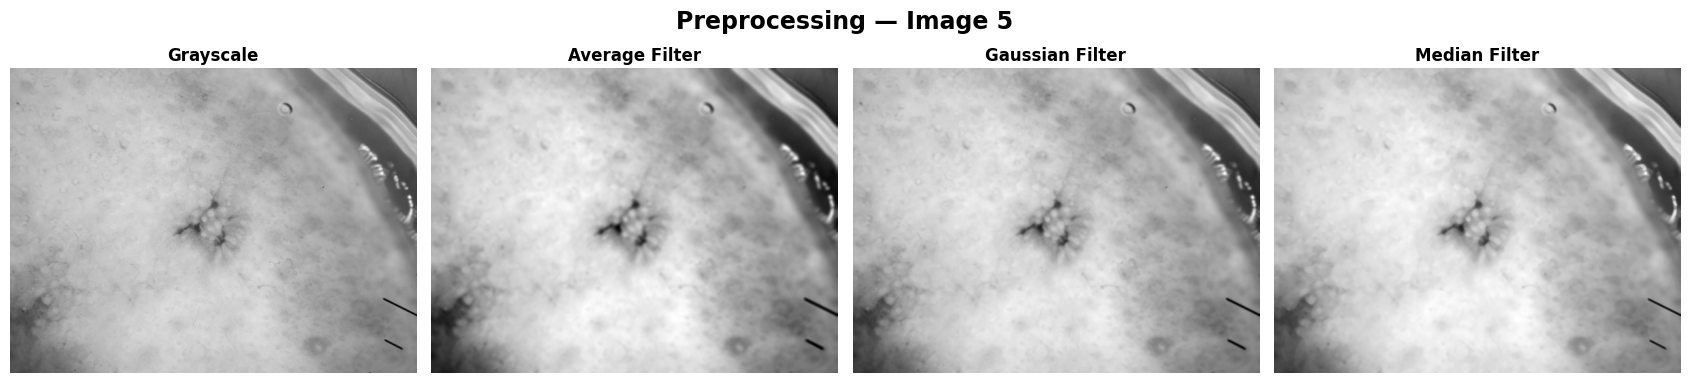

In [5]:
for i in range(1, 6):

    data = processed[f"Image {i}"]

    fig, axes = plt.subplots(1, 4, figsize=(17, 4))

    axes[0].imshow(data["gray"], cmap="gray")
    axes[0].set_title("Grayscale", fontweight="bold")

    axes[1].imshow(data["average"], cmap="gray")
    axes[1].set_title("Average Filter", fontweight="bold")

    axes[2].imshow(data["gaussian"], cmap="gray")
    axes[2].set_title("Gaussian Filter", fontweight="bold")

    axes[3].imshow(data["median"], cmap="gray")
    axes[3].set_title("Median Filter", fontweight="bold")

    for ax in axes:
        ax.axis("off")

    plt.suptitle(
        f"Preprocessing — Image {i}",
        fontsize=17,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

# Sobel + All Canny Thresholds

In [6]:
thresholds = [
    (50, 100),
    (100, 200),
    (150, 250)
]

filter_names = [
    "gray",
    "average",
    "gaussian",
    "median"
]

for i in range(1, 6):

    data = processed[f"Image {i}"]

    # -----------------------------
    # SOBEL
    # -----------------------------
    for filter_name in filter_names:

        image = data[filter_name]

        sx = cv2.Sobel(
            image,
            cv2.CV_64F,
            1,
            0,
            ksize=3
        )

        sy = cv2.Sobel(
            image,
            cv2.CV_64F,
            0,
            1,
            ksize=3
        )

        magnitude = cv2.magnitude(
            sx.astype(np.float32),
            sy.astype(np.float32)
        )

        magnitude = cv2.normalize(
            magnitude,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        ).astype(np.uint8)

        data[f"sobel_{filter_name}"] = magnitude

    # -----------------------------
    # CANNY
    # -----------------------------
    for low, high in thresholds:

        for filter_name in filter_names:

            data[f"canny_{low}_{high}_{filter_name}"] = cv2.Canny(
                data[filter_name],
                low,
                high
            )

print("Sobel and all Canny methods completed!")

Sobel and all Canny methods completed!


# Compare Canny Thresholds

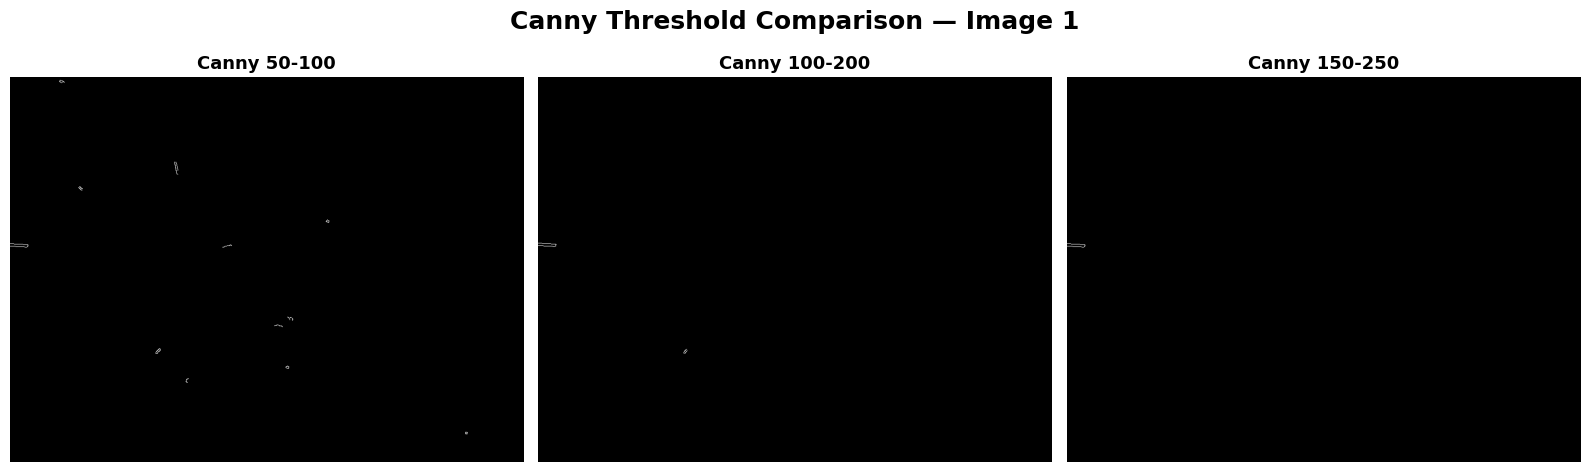

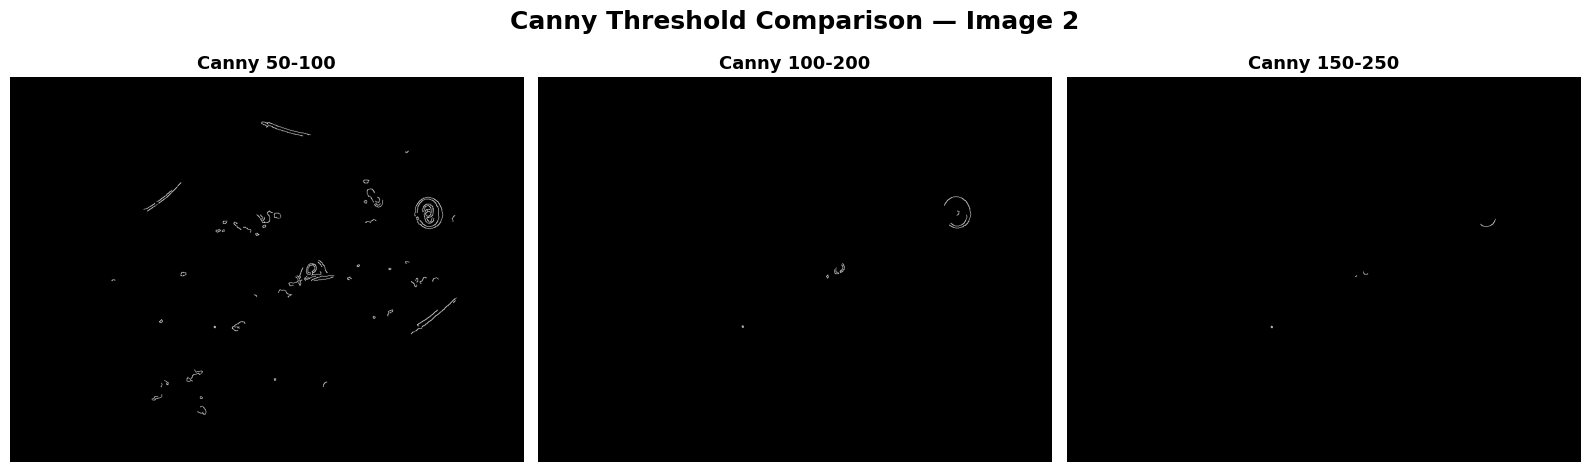

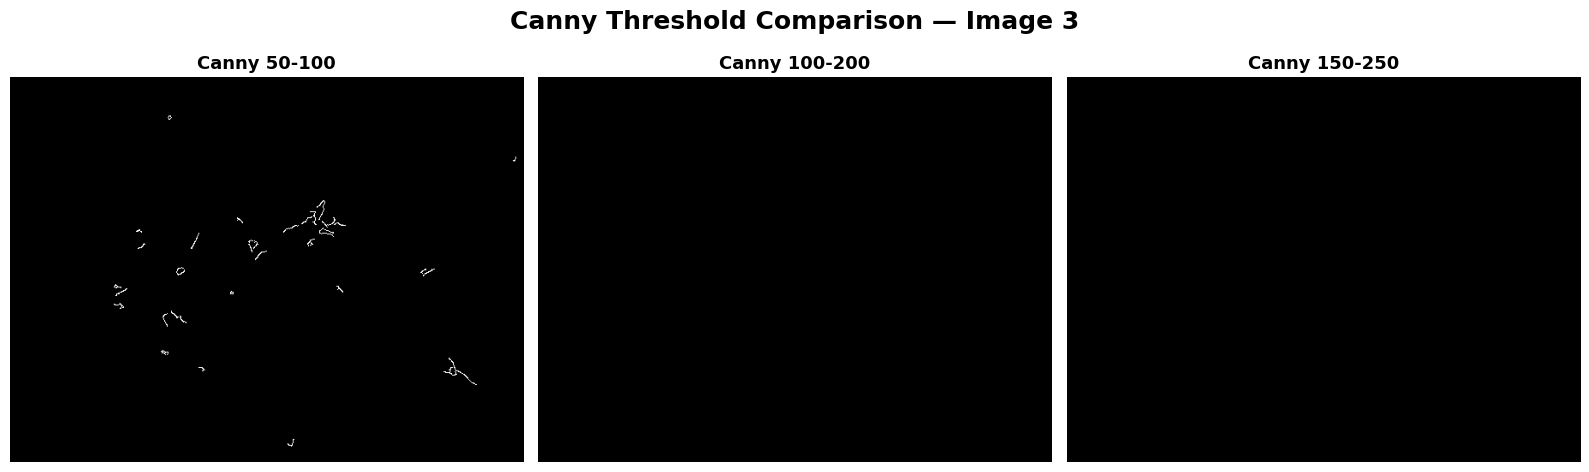

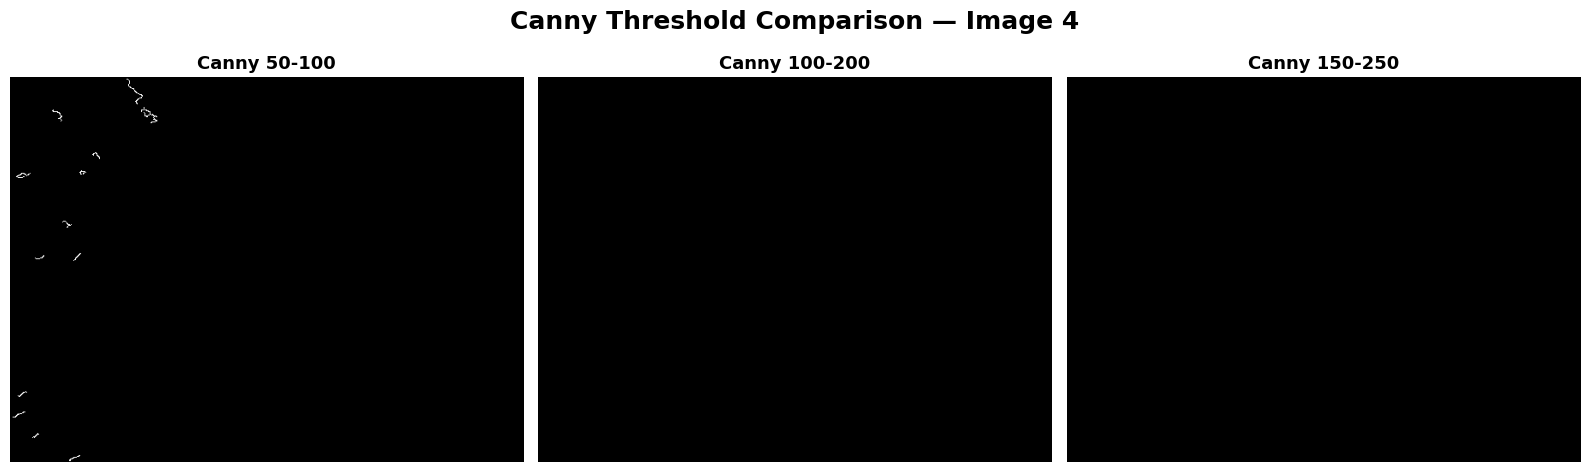

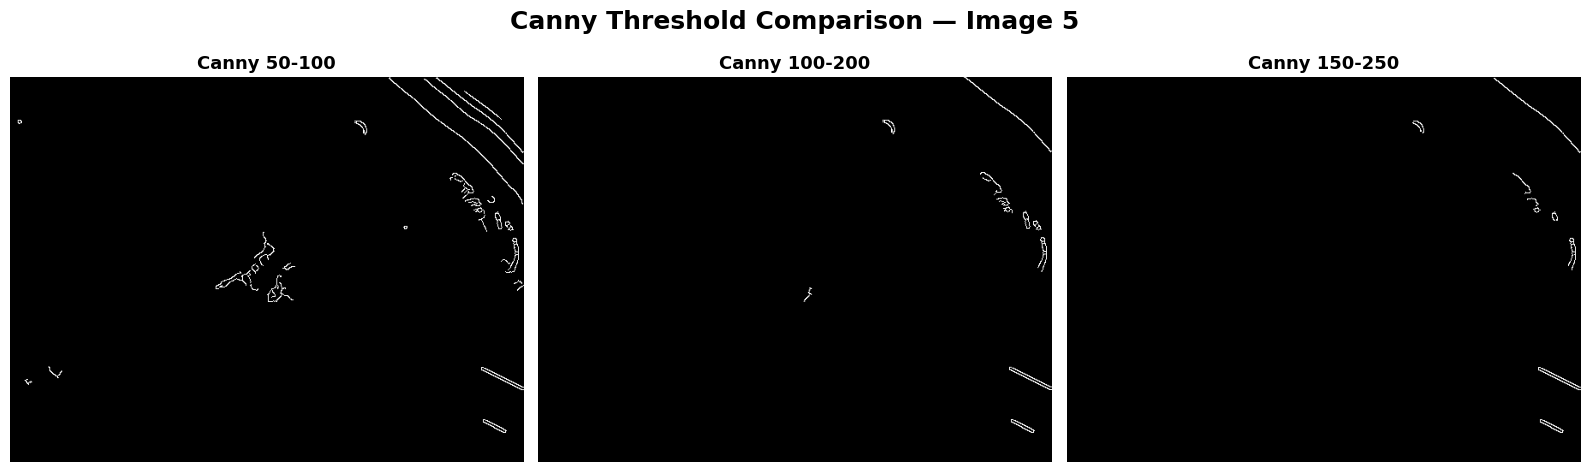

In [7]:
for i in range(1, 6):

    data = processed[f"Image {i}"]

    fig, axes = plt.subplots(
        1, 3,
        figsize=(16, 5)
    )

    for ax, (low, high) in zip(axes, thresholds):

        edge = data[
            f"canny_{low}_{high}_gaussian"
        ]

        ax.imshow(edge, cmap="gray")

        ax.set_title(
            f"Canny {low}-{high}",
            fontsize=13,
            fontweight="bold"
        )

        ax.axis("off")

    plt.suptitle(
        f"Canny Threshold Comparison — Image {i}",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

In [8]:
# Change this ONLY if another threshold looks clearer in Chunk 7

BEST_THRESHOLD = (100, 200)

print(
    f"Selected Canny threshold: "
    f"{BEST_THRESHOLD[0]}-{BEST_THRESHOLD[1]}"
)

Selected Canny threshold: 100-200


# Lesion Boundary + Area + Perimeter

In [9]:
def get_contour_metrics(edge):

    # Convert edge image into binary image
    _, binary = cv2.threshold(
        edge,
        50,
        255,
        cv2.THRESH_BINARY
    )

    # Morphological closing
    kernel = np.ones((5, 5), np.uint8)

    closed = cv2.morphologyEx(
        binary,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    # Find contours
    contours, _ = cv2.findContours(
        closed,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Remove very small contours
    contours = [
        c for c in contours
        if cv2.contourArea(c) > 100
    ]

    if not contours:
        return None, 0, 0

    # Select largest contour
    contour = max(
        contours,
        key=cv2.contourArea
    )

    area = cv2.contourArea(contour)

    perimeter = cv2.arcLength(
        contour,
        True
    )

    return contour, area, perimeter


results = []

low, high = BEST_THRESHOLD

for i in range(1, 6):

    data = processed[f"Image {i}"]

    # Gaussian + selected Canny
    edges = data[
        f"canny_{low}_{high}_gaussian"
    ]

    contour, area, perimeter = get_contour_metrics(
        edges
    )

    # Copy original image
    boundary = data["original"].copy()

    # Draw lesion boundary
    if contour is not None:

        cv2.drawContours(
            boundary,
            [contour],
            -1,
            (120, 170, 130),
            3
        )

    data["boundary"] = boundary
    data["contour"] = contour

    results.append({
        "Image": f"Image {i}",
        "Best Filter": "Gaussian",
        "Edge Method": f"Canny {low}-{high}",
        "Area (pixels)": round(area, 2),
        "Perimeter (pixels)": round(perimeter, 2)
    })


results_df = pd.DataFrame(results)

print("Lesion measurements:")
display(results_df)

Lesion measurements:


,Image,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
0,Image 1,Gaussian,Canny 100-200,168.5,81.90
1,Image 2,Gaussian,Canny 100-200,317.5,297.66
2,Image 3,Gaussian,Canny 100-200,0.0,0.00
3,Image 4,Gaussian,Canny 100-200,0.0,0.00
4,Image 5,Gaussian,Canny 100-200,313.0,147.40


# Required Visualization Pipeline

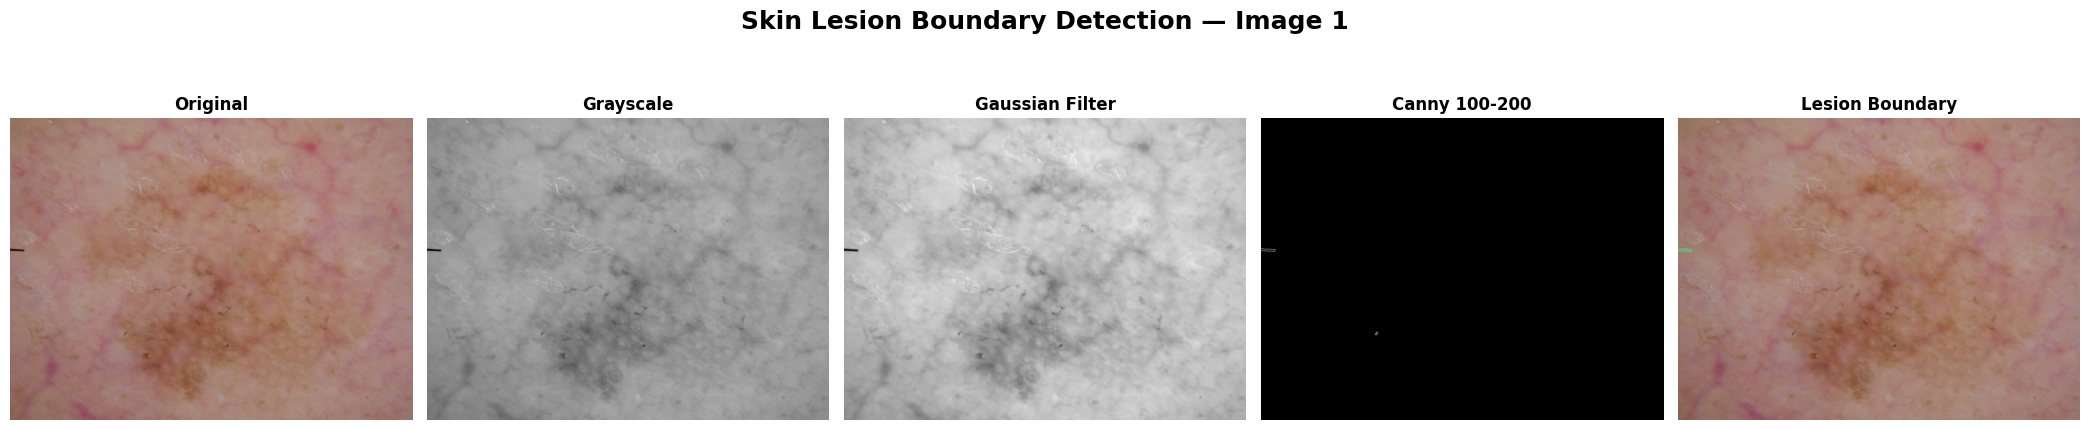

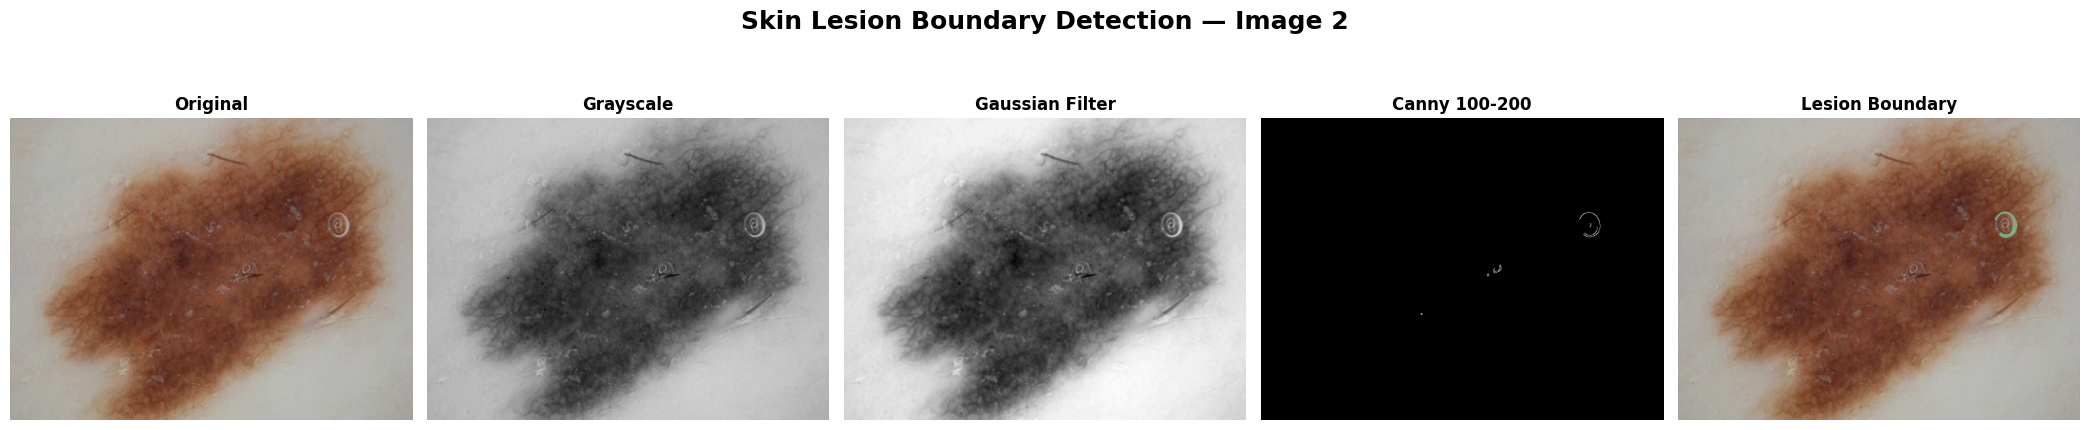

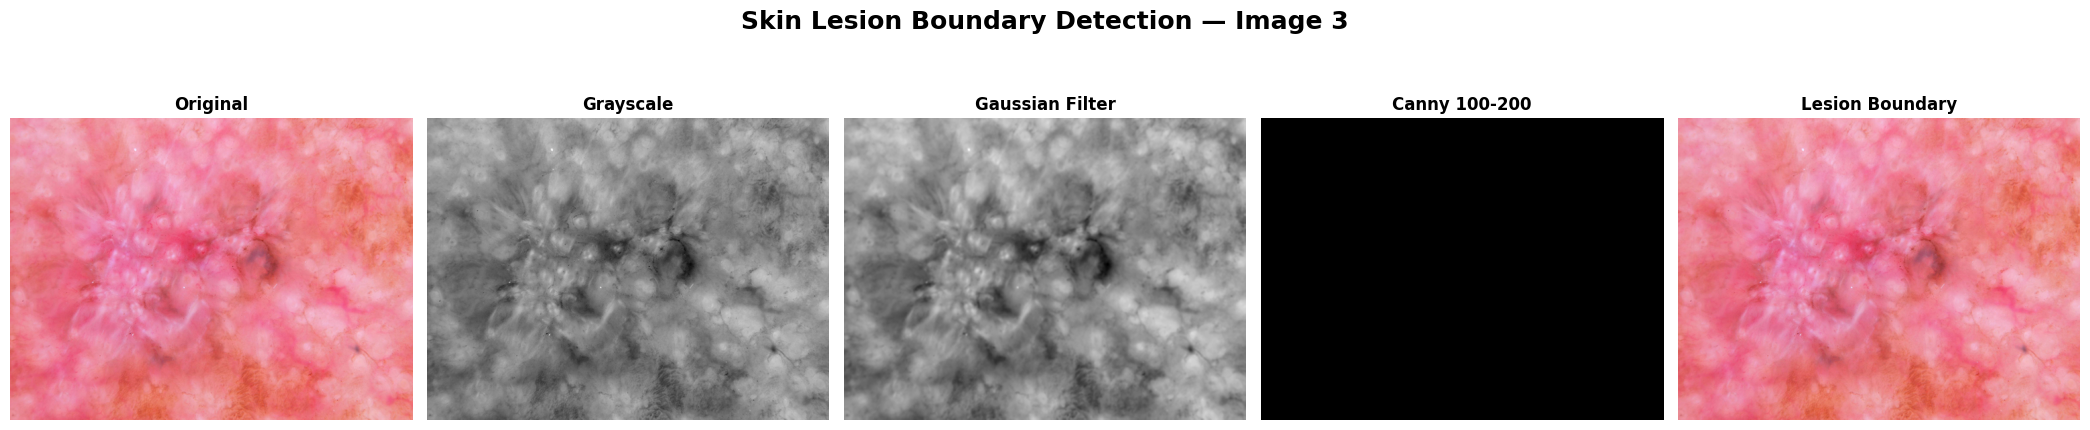

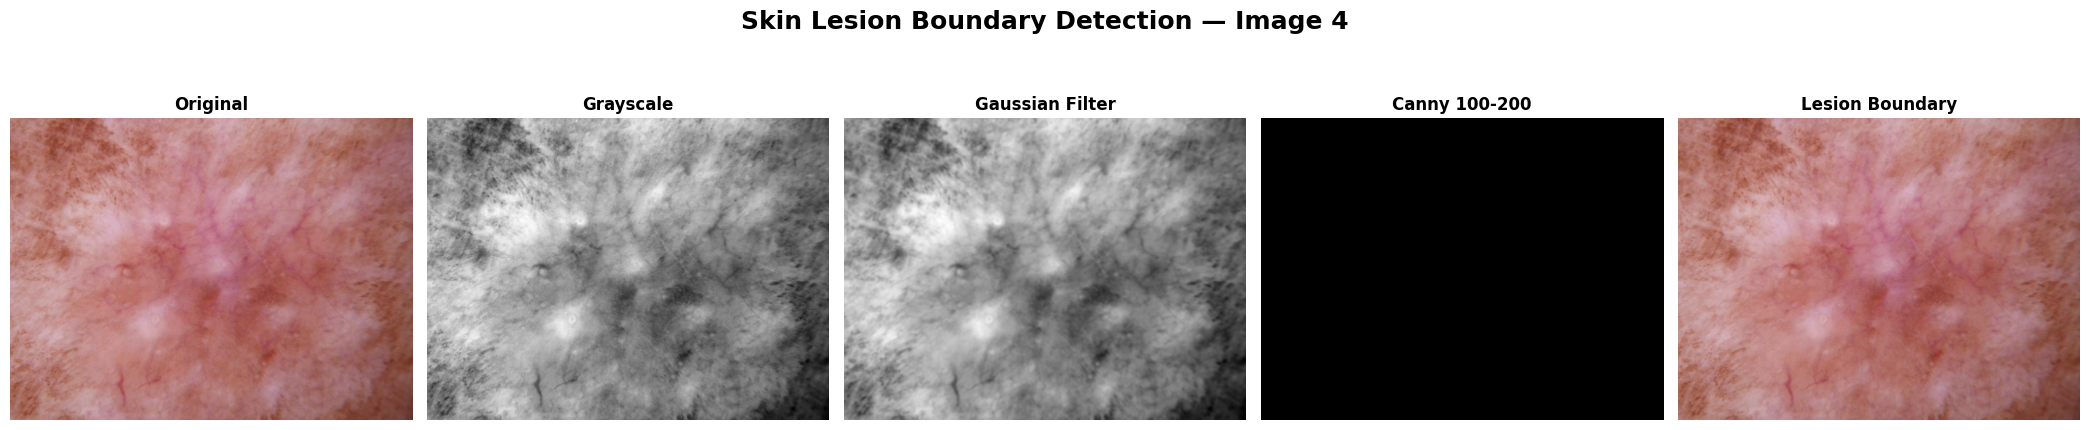

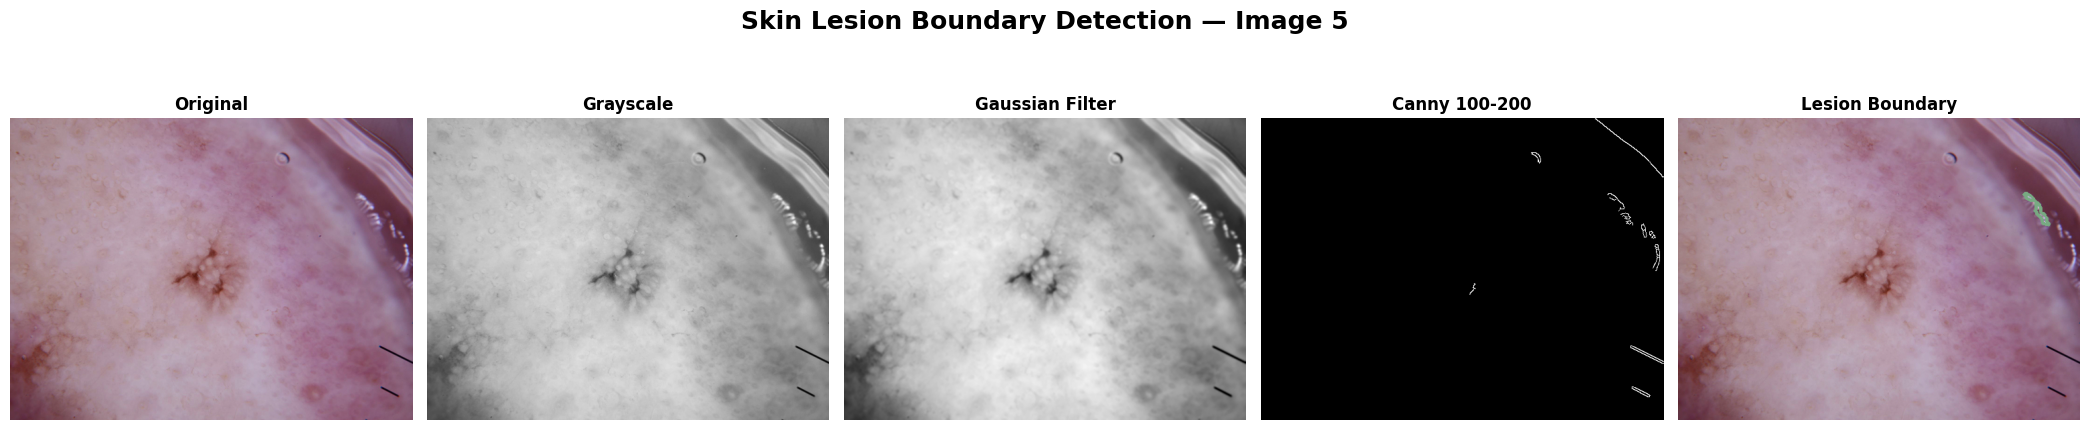

In [10]:
for i in range(1, 6):

    data = processed[f"Image {i}"]

    low, high = BEST_THRESHOLD

    canny = data[
        f"canny_{low}_{high}_gaussian"
    ]

    fig, axes = plt.subplots(
        1,
        5,
        figsize=(21, 5)
    )

    # Original
    axes[0].imshow(data["original"])
    axes[0].set_title(
        "Original",
        fontweight="bold"
    )

    # Grayscale
    axes[1].imshow(
        data["gray"],
        cmap="gray"
    )
    axes[1].set_title(
        "Grayscale",
        fontweight="bold"
    )

    # Gaussian
    axes[2].imshow(
        data["gaussian"],
        cmap="gray"
    )
    axes[2].set_title(
        "Gaussian Filter",
        fontweight="bold"
    )

    # Canny
    axes[3].imshow(
        canny,
        cmap="gray"
    )
    axes[3].set_title(
        f"Canny {low}-{high}",
        fontweight="bold"
    )

    # Boundary
    axes[4].imshow(
        data["boundary"]
    )
    axes[4].set_title(
        "Lesion Boundary",
        fontweight="bold"
    )

    for ax in axes:
        ax.axis("off")

    plt.suptitle(
        f"Skin Lesion Boundary Detection — Image {i}",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

# 8 Methods +  Graphs

In [11]:
methods = [
    ("Original", "gray", "sobel_gray"),
    ("Average", "average", "sobel_average"),
    ("Gaussian", "gaussian", "sobel_gaussian"),
    ("Median", "median", "sobel_median")
]

comparison = []

low, high = BEST_THRESHOLD

for i in range(1, 6):

    data = processed[f"Image {i}"]

    for filter_name, filter_key, sobel_key in methods:

        # =====================================
        # SOBEL
        # =====================================

        sobel = data[sobel_key]

        sobel_contour, sobel_area, sobel_perimeter = (
            get_contour_metrics(sobel)
        )

        comparison.append({
            "Image": f"Image {i}",
            "Method": f"{filter_name} + Sobel",
            "Area (pixels)": round(sobel_area, 2),
            "Perimeter (pixels)": round(
                sobel_perimeter,
                2
            )
        })

        # =====================================
        # CANNY
        # =====================================

        canny = data[
            f"canny_{low}_{high}_{filter_key}"
        ]

        canny_contour, canny_area, canny_perimeter = (
            get_contour_metrics(canny)
        )

        comparison.append({
            "Image": f"Image {i}",
            "Method": f"{filter_name} + Canny",
            "Area (pixels)": round(canny_area, 2),
            "Perimeter (pixels)": round(
                canny_perimeter,
                2
            )
        })


comparison_df = pd.DataFrame(comparison)

print("Complete 8-method comparison:")
display(comparison_df)


# ==========================================
# AVERAGE RESULTS
# ==========================================

summary = (
    comparison_df
    .groupby("Method")[
        ["Area (pixels)", "Perimeter (pixels)"]
    ]
    .mean()
    .reset_index()
    .round(2)
)

print("Average results across 5 images:")
display(summary)


# ==========================================
# ATTRACTIVE COLOR PALETTE
# ==========================================

METHOD_COLORS = [
    "#A3B18A",  # Sage
    "#D8A7B1",  # Tea Pink
    "#B8A9C9",  # Soft Purple
    "#A8A9AD",  # Zinc
    "#8FAF9A",  # Deep Sage
    "#C98F9D",  # Dusty Rose
    "#9A8FBF",  # Muted Purple
    "#7F858A"   # Dark Zinc
]

color_map = {
    method: color
    for method, color in zip(
        summary["Method"],
        METHOD_COLORS
    )
}


# ==========================================
# AREA GRAPH
# ==========================================

fig_area = px.bar(
    summary,
    x="Method",
    y="Area (pixels)",
    color="Method",
    color_discrete_map=color_map,
    title="Average Detected Lesion Area — 8 Methods",
    hover_data=[
        "Perimeter (pixels)"
    ]
)

fig_area.update_layout(
    template="simple_white",
    title_x=0.5,
    title_font_size=22,
    xaxis_title="Method",
    yaxis_title="Average Area (pixels)",
    showlegend=False,
    xaxis_tickangle=-35
)

fig_area.show()


# ==========================================
# PERIMETER GRAPH
# ==========================================

fig_perimeter = px.bar(
    summary,
    x="Method",
    y="Perimeter (pixels)",
    color="Method",
    color_discrete_map=color_map,
    title="Average Detected Lesion Perimeter — 8 Methods"
)

fig_perimeter.update_layout(
    template="simple_white",
    title_x=0.5,
    title_font_size=22,
    xaxis_title="Method",
    yaxis_title="Average Perimeter (pixels)",
    showlegend=False,
    xaxis_tickangle=-35
)

fig_perimeter.show()


print("All processing and visualizations completed successfully! 🎉")

Complete 8-method comparison:


,Image,Method,Area (pixels),Perimeter (pixels)
0,Image 1,Original + Sobel,264.0,134.97
1,Image 1,Original + Canny,165.5,81.07
2,Image 1,Average + Sobel,377.0,95.31
3,Image 1,Average + Canny,185.0,82.49
4,Image 1,Gaussian + Sobel,309.0,91.31
5,Image 1,Gaussian + Canny,168.5,81.90
6,Image 1,Median + Sobel,236.0,86.14
7,Image 1,Median + Canny,165.0,81.31
8,Image 2,Original + Sobel,2117.0,208.85
9,Image 2,Original + Canny,2152.0,211.68


Average results across 5 images:


,Method,Area (pixels),Perimeter (pixels)
0,Average + Canny,91.8,42.31
1,Average + Sobel,77007.2,2680.19
2,Gaussian + Canny,159.8,105.39
3,Gaussian + Sobel,57878.7,3443.07
4,Median + Canny,186.6,93.40
5,Median + Sobel,39774.6,2769.00
6,Original + Canny,600.8,118.56
7,Original + Sobel,27292.0,1685.33


All processing and visualizations completed successfully! 🎉
